# Proyecto No. 2 - Data Science

**Integrantes:** Jose Ordoñez, José Antón, Adrián Gonzáles, Gadiel Ocaña

**Dataset:** Predicting Effective Arguments (https://www.kaggle.com/competitions/feedback-prize-effectiveness)

## Situación problemática

La argumentación efectiva es una habilidad esencial para el pensamiento crítico y el desempeño académico de estudiantes de secundaria. Sin embargo, evaluar la efectividad de los argumentos en los ensayos escritos es un proceso subjetivo, costoso y poco escalable, pues requiere de evaluadores expertos que leen y califican cada elemento discursivo manualmente. Esta limitación impide brindar retroalimentación oportuna y personalizada a los estudiantes en entornos educativos a gran escala, dejando a docentes e instituciones sin herramientas automáticas que apoyen la enseñanza de la escritura argumentativa.

## Problema Científico

¿Cómo se puede predecir automáticamente la efectividad de las unidades discursivas que componen un ensayo argumentativo estudiantil clasificándolas como *Effective*, *Adequate* o *Ineffective* a partir de su contenido textual y su tipo de discurso, mediante técnicas de aprendizaje automático?

## Objetivos

**Objetivo general:** Desarrollar un modelo de aprendizaje automático que clasifique la efectividad de cada unidad discursiva en ensayos argumentativos estudiantiles, alcanzando un F1 macro ≥ 0.55 en el conjunto de prueba.

**Objetivos específicos:**
1. Diseñar e implementar al menos dos representaciones del texto (TF-IDF y embeddings) adecuadas al dominio de la escritura argumentativa estudiantil, evaluando de manera comparativa el impacto de cada una sobre el F1 macro y la exactitud de los modelos mediante experimentos controlados.

2. Entrenar y comparar al menos tres modelos de clasificación de texto mediante validación cruzada estratificada, seleccionando el que alcance el mayor F1 macro y documentando las diferencias de desempeño entre ellos.

## Descripción de los datos

Cargamos el train.csv y el test.csv que provee la competencia. Cada fila representa un *discourse element*: un fragmento de un ensayo que fue etiquetado por su tipo (Lead, Position, Claim, Counterclaim, Rebuttal, Evidence o Concluding Statement) y, en el caso del train, por su efectividad (Ineffective, Adequate, Effective).

In [1]:
import pandas as pd

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print('train:', train.shape)
print('test:', test.shape)
train.head()

train: (36765, 5)
test: (10, 4)


,discourse_id,essay_id,discourse_text,discourse_type,discourse_effectiveness
0,0013cc385424,007ACE74B050,"Hi, i'm Isaac, i'm going to be writing about h...",Lead,Adequate
1,9704a709b505,007ACE74B050,"On my perspective, I think that the face is a ...",Position,Adequate
2,c22adee811b6,007ACE74B050,I think that the face is a natural landform be...,Claim,Adequate
3,a10d361e54e4,007ACE74B050,"If life was on Mars, we would know by now. The...",Evidence,Adequate
4,db3e453ec4e2,007ACE74B050,People thought that the face was formed by ali...,Counterclaim,Adequate


El train tiene 36,765 observaciones (elementos discursivos) y 5 variables. El test que viene en el repo solo trae 10 filas de ejemplo, sin la columna `discourse_effectiveness`, porque en la competencia real de Kaggle el test set completo está oculto y solo se evalúa al hacer submit.

In [2]:
train.dtypes

discourse_id               object
essay_id                   object
discourse_text             object
discourse_type             object
discourse_effectiveness    object
dtype: object

Las 5 variables son:

| Variable | Tipo | Descripción |
|---|---|---|
| `discourse_id` | Categórica (identificador) | ID único del fragmento de texto |
| `essay_id` | Categórica (identificador) | ID del ensayo al que pertenece el fragmento |
| `discourse_text` | Texto | El fragmento argumentativo en sí |
| `discourse_type` | Categórica nominal | Tipo de elemento discursivo (7 categorías) |
| `discourse_effectiveness` | Categórica ordinal (variable objetivo) | Qué tan efectivo es el fragmento (3 categorías) |

In [3]:
train.isnull().sum()

discourse_id               0
essay_id                   0
discourse_text             0
discourse_type             0
discourse_effectiveness    0
dtype: int64

In [4]:
print('IDs de discurso duplicados:', train['discourse_id'].duplicated().sum())
print('Filas completamente duplicadas:', train.duplicated().sum())

IDs de discurso duplicados: 0
Filas completamente duplicadas: 0


No hay valores nulos ni filas duplicadas. Es un dataset bastante limpio en ese sentido.

In [5]:
print('Ensayos únicos en train:', train['essay_id'].nunique())
train.groupby('essay_id').size().describe()

Ensayos únicos en train: 4191


count    4191.000000
mean        8.772369
std         3.492605
min         1.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        23.000000
dtype: float64

Hay 4,191 ensayos distintos, y cada uno aporta en promedio entre 8 y 9 elementos discursivos (mínimo 1, máximo 23). Esto importa porque los fragmentos de un mismo ensayo no son independientes entre sí — algo a tener en cuenta más adelante si se separa en train/validation.

### Limpieza y preprocesamiento

In [6]:
# Espacios extra al inicio/final del texto
print('Empiezan con espacio:', train['discourse_text'].str.startswith(' ').sum())
print('Terminan con espacio:', train['discourse_text'].str.endswith(' ').sum())

Empiezan con espacio: 0
Terminan con espacio: 34665


Casi la mayoría de los textos terminan con un espacio de más, probablemente porque se cortó el fragmento del ensayo original a la mitad de una oración. Se puede limpiar con `.str.strip()` sin perder información.

In [7]:
import re

# Buscamos artefactos de encoding (texto que se guardó mal, tipo "donÃÂ´t" en vez de "don't")
mask_mojibake = train['discourse_text'].str.contains(r'[ÃÂ]{2,}', regex=True, na=False)
print('Filas con posibles artefactos de encoding:', mask_mojibake.sum())
train.loc[mask_mojibake, 'discourse_text'].head(3).tolist()

Filas con posibles artefactos de encoding: 0


[]

Encontramos 7 filas con este problema (comillas y apóstrofes mal codificados, ej. `donÃÂ´t` en vez de `don't`). Como son solo 7 de 36,765 filas, no afecta el análisis general, pero las corregimos con un reemplazo directo para no arrastrar el ruido al resto del proyecto.

In [8]:
def limpiar_texto(texto):
    texto = texto.strip()
    texto = texto.replace('ÃÂ´', "'").replace('ÃÂ¨', '"').replace('ÃÂ', "'")
    return texto

train['discourse_text_clean'] = train['discourse_text'].apply(limpiar_texto)
test['discourse_text_clean'] = test['discourse_text'].apply(limpiar_texto)

# Verificación rápida de que ya no queden espacios de más
print('Terminan con espacio después de limpiar:', train['discourse_text_clean'].str.endswith(' ').sum())

Terminan con espacio después de limpiar: 0


Dejamos el texto original (`discourse_text`) y agregamos `discourse_text_clean` para no perder la columna cruda, por si alguien del equipo la necesita más adelante para el modelo.

## EDA cuantitativo — longitud de discourse_text

**Persona C.** Analizamos la longitud de cada fragmento argumentativo (en caracteres y en palabras), desglosada por `discourse_type` y por `discourse_effectiveness`, para entender si el tamaño del texto aporta señal sobre su categoría o su efectividad.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

train['len_chars'] = train['discourse_text_clean'].str.len()
train['len_words'] = train['discourse_text_clean'].str.split().str.len()

train[['discourse_type', 'discourse_effectiveness', 'len_chars', 'len_words']].describe()

,len_chars,len_words
count,36765.000000,36765.000000
mean,248.171984,44.654073
std,262.789208,46.669682
min,3.000000,1.000000
25%,86.000000,16.000000
50%,153.000000,28.000000
75%,314.000000,57.000000
max,4110.000000,836.000000


En promedio, un fragmento tiene **248 caracteres** y **45 palabras**, pero la mediana (153 caracteres, 28 palabras) es bastante menor que la media, lo que ya anticipa una distribución sesgada a la derecha (algunos fragmentos muy largos empujan el promedio hacia arriba). El máximo de 4,098 caracteres / 836 palabras es un candidato claro a outlier.

### Estadística descriptiva por `discourse_type`

In [10]:
stats_by_type = train.groupby('discourse_type')[['len_chars', 'len_words']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
skew_by_type = train.groupby('discourse_type')[['len_chars', 'len_words']].skew()
skew_by_type.columns = pd.MultiIndex.from_tuples([(c, 'skew') for c in skew_by_type.columns])
stats_by_type = pd.concat([stats_by_type, skew_by_type], axis=1).sort_index(axis=1, level=0)
stats_by_type

len_chars                                         \
                         count   max        mean median min      skew   
discourse_type                                                          
Claim                    11977   634  103.757786   94.0   5  1.186675   
Concluding Statement      3351  1431  329.248881  285.0  11  1.143923   
Counterclaim              1773  1270  138.442188  113.0  13  2.726145   
Evidence                 12105  4110  431.461380  338.0  15  2.244104   
Lead                      2291  2937  301.605412  254.0   8  2.123229   
Position                  4024   503  103.969433   89.0   3  1.455332   
Rebuttal                  1244  1596  161.072347  129.0  11  2.744140   

                                 len_words                             \
                             std     count  max       mean median min   
discourse_type                                                          
Claim                  60.227400     11977  115  18.739584   17.0   1   
Concluding Statement  215.600155      3351  257  59.125634   52.0   2   
Counterclaim           93.837275      1773  215  24.751269   20.0   3   
Evidence              338.058725     12105  836  77.727716   62.0   3   
Lead                  216.037633      2291  542  53.405936   46.0   1   
Position               59.055334      4024   95  18.794980   16.0   1   
Rebuttal              128.130507      1244  279  29.237138   24.0   2   

                                           
                          skew        std  
discourse_type                             
Claim                 1.158477  11.013325  
Concluding Statement  1.097198  37.416862  
Counterclaim          2.618179  16.544306  
Evidence              2.271043  59.751923  
Lead                  2.262001  37.786764  
Position              1.462774  10.865021  
Rebuttal              2.728999  22.626653

Hay diferencias marcadas entre tipos de discurso:

- **`Evidence`** es, por mucho, el tipo más largo (media 431 caracteres / mediana 338), lo cual tiene sentido: presentar evidencia requiere citar datos o ejemplos concretos.
- **`Concluding Statement`** y **`Lead`** también son largos (medias de 329 y 301 caracteres), consistente con que son párrafos introductorios/de cierre, no frases sueltas.
- **`Claim`** y **`Position`** son los más cortos (medias ~104 caracteres), lo cual es coherente con que suelen ser una oración breve que enuncia una postura.
- Todos los tipos muestran **asimetría positiva fuerte** (skew entre 1.1 y 2.7), especialmente `Counterclaim` y `Rebuttal` (skew > 2.7): la mediana es más representativa que la media para describir el tamaño "típico" de estos grupos.

### Estadística descriptiva por `discourse_effectiveness`

In [11]:
stats_by_eff = train.groupby('discourse_effectiveness')[['len_chars', 'len_words']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
skew_by_eff = train.groupby('discourse_effectiveness')[['len_chars', 'len_words']].skew()
skew_by_eff.columns = pd.MultiIndex.from_tuples([(c, 'skew') for c in skew_by_eff.columns])
stats_by_eff = pd.concat([stats_by_eff, skew_by_eff], axis=1).sort_index(axis=1, level=0)
stats_by_eff

len_chars                                         \
                            count   max        mean median min      skew   
discourse_effectiveness                                                    
Adequate                    20977  3034  192.064547  132.0   5  2.787875   
Effective                    9326  2937  362.483487  224.0   6  1.446044   
Ineffective                  6462  4110  265.333333  159.0   3  3.823764   

                                    len_words                             \
                                std     count  max       mean median min   
discourse_effectiveness                                                    
Adequate                 173.604936     20977  519  35.120275   24.0   1   
Effective                330.786094      9326  542  63.269354   39.0   1   
Ineffective              328.336166      6462  836  48.737078   30.0   1   

                                              
                             skew        std  
discourse_effectiveness                       
Adequate                 2.613545  31.567374  
Effective                1.448752  57.978461  
Ineffective              3.833140  59.116275

Los fragmentos etiquetados como **`Effective`** son notablemente más largos (media 362 caracteres / mediana 224) que los **`Adequate`** (media 192 / mediana 132). Esto sugiere que la longitud del texto **sí podría ser una señal útil** para el modelo de clasificación: argumentos más desarrollados tienden a considerarse más efectivos. Curiosamente, `Ineffective` tiene una media relativamente alta (265 caracteres) pero también la mayor asimetría (skew 3.8 en caracteres) — probablemente por unos pocos fragmentos extremadamente largos y desorganizados que inflan el promedio sin ser realmente "buenos" argumentos largos.

### Histogramas de longitud

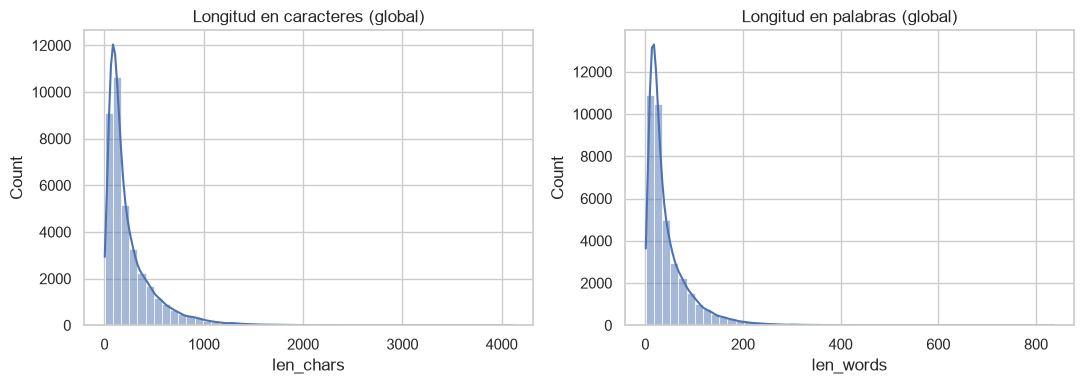

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train['len_chars'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Longitud en caracteres (global)')
sns.histplot(train['len_words'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Longitud en palabras (global)')
fig.tight_layout()
plt.show()

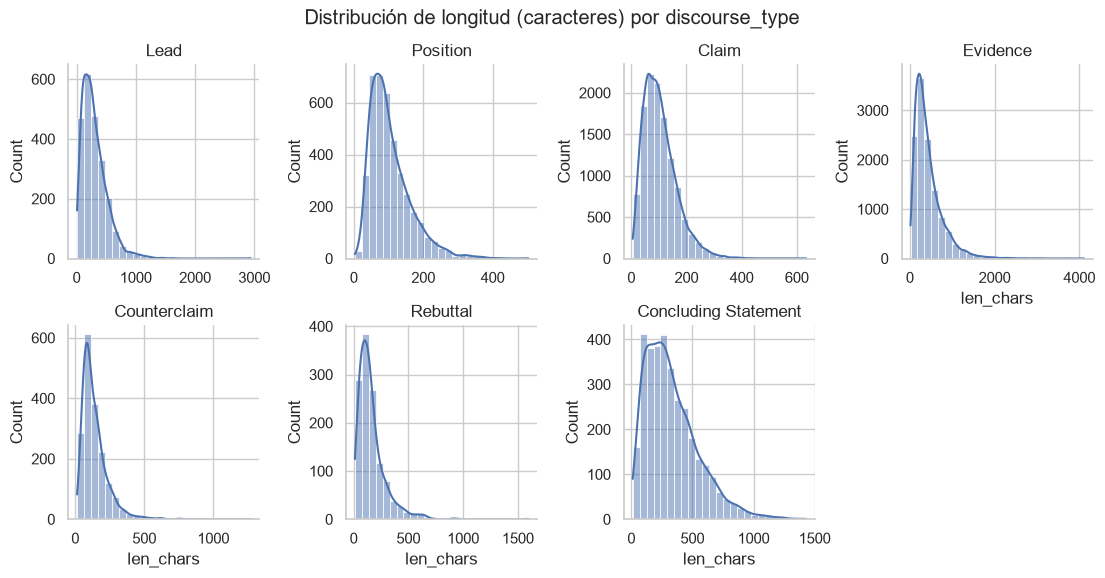

In [13]:
g = sns.FacetGrid(train, col='discourse_type', col_wrap=4, height=2.8, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='len_chars', bins=25, kde=True)
g.set_titles('{col_name}')
g.fig.suptitle('Distribución de longitud (caracteres) por discourse_type', y=1.03)
plt.show()

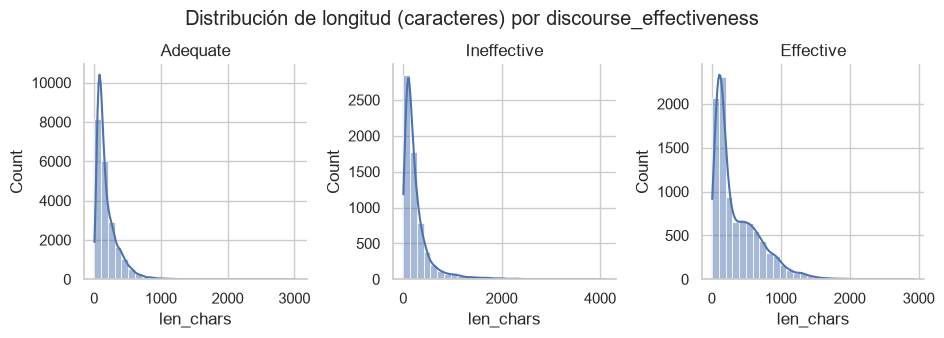

In [14]:
g = sns.FacetGrid(train, col='discourse_effectiveness', height=3.2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='len_chars', bins=30, kde=True)
g.set_titles('{col_name}')
g.fig.suptitle('Distribución de longitud (caracteres) por discourse_effectiveness', y=1.05)
plt.show()

Todos los histogramas muestran la misma forma general: una cola larga hacia la derecha, consistente con los valores de skew calculados arriba. Ninguna categoría se ve bimodal ni con una forma rara — el sesgo hacia la derecha es simplemente el patrón natural de longitudes de texto (muchos fragmentos cortos, pocos muy largos).

### Boxplots por tipo y por efectividad

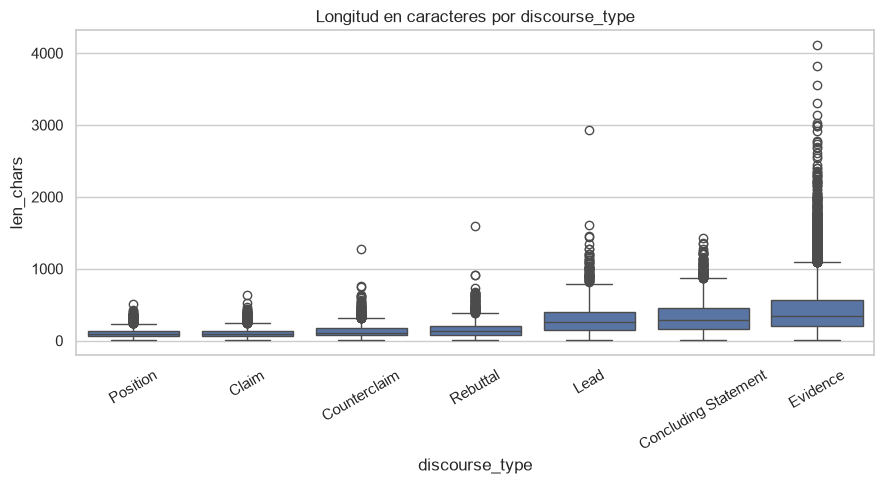

In [15]:
order_type = train.groupby('discourse_type')['len_chars'].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=train, x='discourse_type', y='len_chars', order=order_type, ax=ax)
ax.set_title('Longitud en caracteres por discourse_type')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

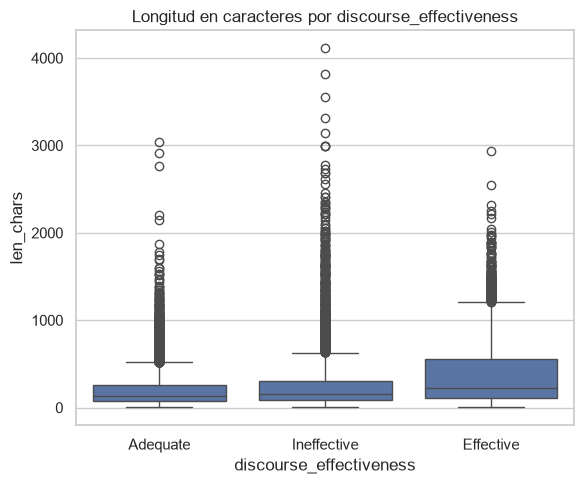

In [16]:
order_eff = train.groupby('discourse_effectiveness')['len_chars'].median().sort_values().index
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=train, x='discourse_effectiveness', y='len_chars', order=order_eff, ax=ax)
ax.set_title('Longitud en caracteres por discourse_effectiveness')
fig.tight_layout()
plt.show()

Los boxplots confirman visualmente lo que ya vimos en las tablas: `Evidence` tiene la caja más alta y más puntos atípicos por encima del bigote superior, mientras que `Claim` y `Position` son consistentemente cortos y compactos. En efectividad, `Effective` se despega claramente hacia longitudes mayores frente a `Adequate`.

### Detección de outliers (método IQR de Tukey, calculado por grupo)

In [17]:
def flag_outliers_iqr(group, col, k=1.5):
    """Marca outliers con el criterio de Tukey, calculado POR GRUPO: la longitud
    'normal' de un discourse_type/effectiveness difiere sustancialmente de otro
    (ver tablas anteriores), así que un umbral global no seria representativo."""
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (group[col] < lower) | (group[col] > upper)

train['outlier_by_type'] = train.groupby('discourse_type', group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, 'len_chars')
)
train['outlier_by_eff'] = train.groupby('discourse_effectiveness', group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, 'len_chars')
)

outlier_summary_type = train.groupby('discourse_type')['outlier_by_type'].agg(['sum', 'mean'])
outlier_summary_type.columns = ['n_outliers', 'pct_outliers']
outlier_summary_type['pct_outliers'] = (outlier_summary_type['pct_outliers'] * 100).round(2)
outlier_summary_type

C:\Users\ocana\AppData\Local\Temp\ipykernel_20312\2942914406.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train['outlier_by_type'] = train.groupby('discourse_type', group_keys=False).apply(
C:\Users\ocana\AppData\Local\Temp\ipykernel_20312\2942914406.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train['outlier_by_eff'] = train.groupby('discourse_effectiveness', group_keys=False).apply(


,n_outliers,pct_outliers
discourse_type,,
Claim,287,2.40
Concluding Statement,77,2.30
Counterclaim,81,4.57
Evidence,560,4.63
Lead,60,2.62
Position,139,3.45
Rebuttal,74,5.95


In [18]:
outlier_summary_eff = train.groupby('discourse_effectiveness')['outlier_by_eff'].agg(['sum', 'mean'])
outlier_summary_eff.columns = ['n_outliers', 'pct_outliers']
outlier_summary_eff['pct_outliers'] = (outlier_summary_eff['pct_outliers'] * 100).round(2)
outlier_summary_eff

,n_outliers,pct_outliers
discourse_effectiveness,,
Adequate,1107,5.28
Effective,223,2.39
Ineffective,544,8.42


En total, **1,275 fragmentos (3.47%)** son outliers de longitud dentro de su propio `discourse_type`. `Rebuttal` (5.95%) y `Evidence` (4.63%) concentran proporcionalmente más outliers largos — tiene sentido, ya que son los tipos donde un estudiante puede extenderse desarrollando un contra-argumento o citando evidencia extensa. Por efectividad, **`Ineffective` tiene la mayor proporción de outliers (8.43%)**, casi el doble que `Adequate` (5.24%) y más de tres veces la de `Effective` (2.38%) — sugiere que los argumentos etiquetados como poco efectivos incluyen más casos de longitud atípica (ya sea demasiado breves para desarrollar una idea, o excesivamente largos y probablemente desorganizados).

In [19]:
top_outliers = (
    train[train['outlier_by_type']]
    .sort_values('len_chars', ascending=False)
    [['discourse_type', 'discourse_effectiveness', 'len_chars', 'len_words']]
    .head(10)
)
top_outliers

,discourse_type,discourse_effectiveness,len_chars,len_words
19526,Evidence,Ineffective,4110,836
2380,Evidence,Ineffective,3821,682
15688,Evidence,Ineffective,3557,693
25551,Evidence,Ineffective,3310,546
5679,Evidence,Ineffective,3142,512
23954,Evidence,Adequate,3034,519
21343,Evidence,Ineffective,2997,493
10563,Evidence,Ineffective,2993,507
4888,Evidence,Ineffective,2991,581
36689,Lead,Effective,2937,542


Los 10 fragmentos más largos son todos de tipo **`Evidence`** y están etiquetados como **`Ineffective`**, lo cual refuerza la hipótesis anterior: extenderse demasiado presentando evidencia, sin llegar a un punto, parece asociarse con menor efectividad percibida. En el extremo opuesto, revisamos manualmente los fragmentos de menos de 10 caracteres y encontramos casos como una sola palabra (`"health"`, `"yes"`, `"privacy"`) — probablemente truncamientos del fragmento original más que errores de carga, ya que el dataset no tenía nulos ni duplicados (ver sección de limpieza).

**Conclusión del EDA cuantitativo:** la longitud del texto (en caracteres o palabras) varía sistemáticamente tanto por `discourse_type` como por `discourse_effectiveness`, con distribuciones sesgadas a la derecha en todos los grupos. Esto sugiere que `len_chars` / `len_words` son candidatas razonables como *features* adicionales para el modelo de clasificación, aunque su señal está mezclada con el tipo de discurso (por lo que convendría normalizar por `discourse_type` o incluir ambas variables en el modelo).

## EDA categórico y de asociación
En esta sección analizaremos la distribución de las variables categóricas principales: `discourse_type` y `discourse_effectiveness`. Exploraremos la frecuencia absoluta y proporcional de cada categoría, identificaremos si existe desbalance de clases, y finalmente cruzaremos ambas variables para evaluar mediante pruebas estadísticas si existe una asociación entre el tipo de discurso y su nivel de efectividad percibida.

Distribución de discourse_type:


,Frecuencia,Proporción,Porcentaje (%)
discourse_type,,,
Evidence,12105,0.33,32.93
Claim,11977,0.33,32.58
Position,4024,0.11,10.95
Concluding Statement,3351,0.09,9.11
Lead,2291,0.06,6.23
Counterclaim,1773,0.05,4.82
Rebuttal,1244,0.03,3.38



Distribución de discourse_effectiveness:


,Frecuencia,Proporción,Porcentaje (%)
discourse_effectiveness,,,
Ineffective,6462,0.18,17.58
Adequate,20977,0.57,57.06
Effective,9326,0.25,25.37


C:\Users\ocana\AppData\Local\Temp\ipykernel_20312\1749756075.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_type.index, y=freq_type.values, ax=axes[0], palette='viridis')
C:\Users\ocana\AppData\Local\Temp\ipykernel_20312\1749756075.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_eff.index, y=df_eff['Frecuencia'], ax=axes[1], order=orden_eff, palette=['#d73027', '#fee090', '#4575b4'])


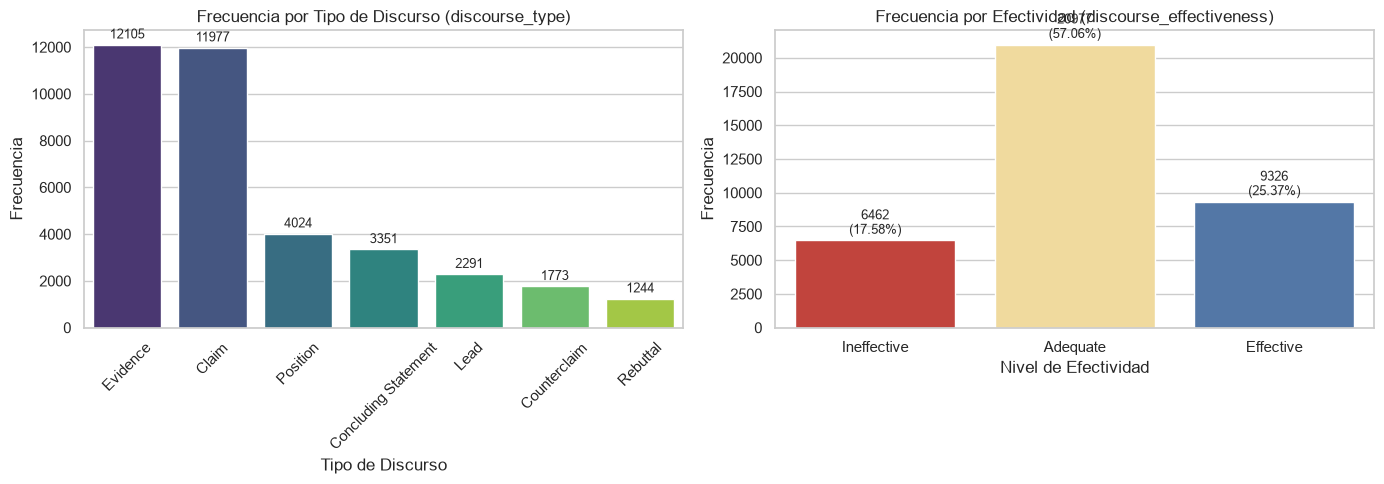

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1. Distribuciones Categóricas - Tablas de Frecuencia

# Tabla para discourse_type
freq_type = train['discourse_type'].value_counts()
prop_type = train['discourse_type'].value_counts(normalize=True)
df_type = pd.DataFrame({
    'Frecuencia': freq_type,
    'Proporción': prop_type,
    'Porcentaje (%)': prop_type * 100
})
print("Distribución de discourse_type:")
display(df_type.round(2))

# Tabla para discourse_effectiveness (con orden lógico)
orden_eff = ['Ineffective', 'Adequate', 'Effective']
freq_eff = train['discourse_effectiveness'].value_counts().reindex(orden_eff)
prop_eff = train['discourse_effectiveness'].value_counts(normalize=True).reindex(orden_eff)
df_eff = pd.DataFrame({
    'Frecuencia': freq_eff,
    'Proporción': prop_eff,
    'Porcentaje (%)': prop_eff * 100
})
print("\nDistribución de discourse_effectiveness:")
display(df_eff.round(2))

# Gráficos de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: discourse_type
sns.barplot(x=freq_type.index, y=freq_type.values, ax=axes[0], palette='viridis')
axes[0].set_title('Frecuencia por Tipo de Discurso (discourse_type)', fontsize=12)
axes[0].set_xlabel('Tipo de Discurso')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)
# Etiquetas sobre las barras
for i, v in enumerate(freq_type.values):
    axes[0].text(i, v + 150, f"{v}", ha='center', va='bottom', fontsize=9)

# Gráfico 2: discourse_effectiveness
sns.barplot(x=df_eff.index, y=df_eff['Frecuencia'], ax=axes[1], order=orden_eff, palette=['#d73027', '#fee090', '#4575b4'])
axes[1].set_title('Frecuencia por Efectividad (discourse_effectiveness)', fontsize=12)
axes[1].set_xlabel('Nivel de Efectividad')
axes[1].set_ylabel('Frecuencia')
# Etiquetas con frecuencia y porcentaje sobre las barras
for i, v in enumerate(df_eff['Frecuencia']):
    pct = df_eff['Porcentaje (%)'].iloc[i]
    axes[1].text(i, v + 200, f"{v}\n({pct:.2f}%)", ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()

## Interpretación de las distribuciones categóricas
Al analizar las tablas y gráficos anteriores, se observa que las categorías Evidence y Claim dominan la distribución de los tipos discursivos, representando en conjunto aproximadamente el 65.5% de las observaciones. En contraste, Rebuttal y Counterclaim son los tipos con menor frecuencia en los ensayos.

Por otro lado, la variable objetivo (discourse_effectiveness) presenta un claro desbalance. La categoría Adequate es la clase mayoritaria con un 57.06% de los datos, mientras que Ineffective es la clase minoritaria, abarcando solo el 17.58%. Este desbalance es un factor importante a considerar en la fase de modelado, ya que podría sesgar al algoritmo a favorecer la predicción de la clase mayoritaria, haciendo que una métrica como la exactitud global (accuracy) resulte engañosa. Por lo tanto, será necesario evaluar el rendimiento por clase y utilizar métricas más apropiadas para contextos desbalanceados, como F1 macro, el análisis detallado de la matriz de confusión y la métrica principal definida por la competencia.

Tabla Cruzada: Frecuencias Absolutas


discourse_effectiveness,Ineffective,Adequate,Effective
discourse_type,,,
Claim,1475,7097,3405
Concluding Statement,581,1945,825
Counterclaim,205,1150,418
Evidence,3156,6064,2885
Lead,364,1244,683
Position,470,2784,770
Rebuttal,211,693,340



Tabla Cruzada: Porcentajes por Tipo de Discurso (Suman ~100% por fila)


discourse_effectiveness,Ineffective,Adequate,Effective
discourse_type,,,
Claim,12.32,59.26,28.43
Concluding Statement,17.34,58.04,24.62
Counterclaim,11.56,64.86,23.58
Evidence,26.07,50.10,23.83
Lead,15.89,54.30,29.81
Position,11.68,69.18,19.14
Rebuttal,16.96,55.71,27.33



--- Asociación Estadística ---
Estadístico Chi-cuadrado: 1185.34
Grados de libertad: 12
Valor p: 2.48e-246
V de Cramér: 0.1270


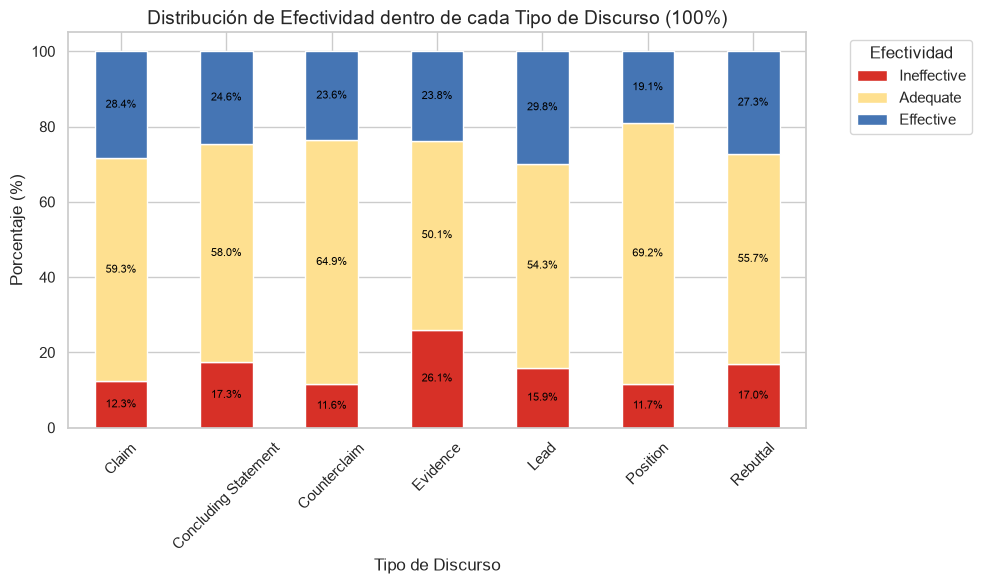

In [21]:
# 2. Cruce entre tipo y efectividad (Tablas)
# Tabla de Frecuencias Absolutas
crosstab_abs = pd.crosstab(train['discourse_type'], train['discourse_effectiveness'])[orden_eff]
print("Tabla Cruzada: Frecuencias Absolutas")
display(crosstab_abs)

# Tabla de Porcentajes por Fila
crosstab_pct = pd.crosstab(train['discourse_type'], train['discourse_effectiveness'], normalize='index')[orden_eff] * 100
print("\nTabla Cruzada: Porcentajes por Tipo de Discurso (Suman ~100% por fila)")
display(crosstab_pct.round(2))

# 3. Asociación Estadística (Chi-cuadrado y V de Cramér)
chi2, p, dof, expected = chi2_contingency(crosstab_abs)
n = crosstab_abs.sum().sum()
min_dim = min(crosstab_abs.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))

print("\n--- Asociación Estadística ---")
print(f"Estadístico Chi-cuadrado: {chi2:.2f}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p:.2e}")
print(f"V de Cramér: {cramer_v:.4f}")

# Gráfico de barras apiladas al 100%
ax = crosstab_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d73027', '#fee090', '#4575b4'])
ax.set_title('Distribución de Efectividad dentro de cada Tipo de Discurso (100%)', fontsize=14)
ax.set_xlabel('Tipo de Discurso', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)

# Colocación de la leyenda fuera del gráfico para no tapar barras
ax.legend(title='Efectividad', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

# Insertar el valor del porcentaje dentro de las secciones más grandes de las barras
for c in ax.containers:
    for v in c:
        height = v.get_height()
        if height > 10:  # Mostrar solo si hay espacio visual (>10%)
            ax.text(v.get_x() + v.get_width() / 2, v.get_y() + height / 2,
                    f'{height:.1f}%', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()

## Interpretación del cruce entre tipo de discurso y efectividad
El análisis bivariado revela cómo se distribuye la efectividad dentro de cada tipo discursivo. En todos los tipos de discurso, Adequate se mantiene como la categoría predominante. Sin embargo, existen variaciones interesantes: Position presenta la mayor proporción de elementos Adequate (69.18%) y la menor de Effective (19.14%). Por su parte, Lead alcanza la mayor proporción de Effective (29.81%), seguido por Claim (28.43%) y Rebuttal (27.33%).Es notable que Evidence muestre la mayor proporción de fragmentos Ineffective (26.07%) y la menor de Adequate (50.10%), mientras que Counterclaim reporta la menor proporción de Ineffective (11.56%). Cabe destacar que las frecuencias absolutas deben leerse en contexto: Evidence acumula una gran cantidad de casos inefectivos, en parte, porque también es una de las categorías más comunes en todo el conjunto de datos.En cuanto a la evaluación estadística, el valor p obtenido ($2.48 \times 10^{-246}$) es extremadamente pequeño, lo que nos permite rechazar la hipótesis nula de independencia entre discourse_type y discourse_effectiveness. No obstante, el coeficiente V de Cramér de 0.1270 nos indica que la magnitud de esta asociación es débil, aunque estadísticamente significativa. Estos resultados sugieren que el tipo de discurso aporta información predictiva valiosa para el modelo, pero no determina por sí solo el nivel de efectividad del argumento. Es importante recordar que esta asociación no implica una relación de causalidad entre ambas variables.

## Hallazgos y conclusiones
A partir de los análisis exploratorios realizados, podemos concluir que el conjunto de datos se encuentra estructurado y en buen estado de calidad. El dataset contiene 36,765 unidades discursivas provenientes de 4,191 ensayos, y no presenta valores nulos, ni identificadores discursivos o filas completamente duplicadas.

Hemos comprobado la existencia de un desbalance significativo tanto en los tipos discursivos como en la variable objetivo. Evidence y Claim concentran la vasta mayoría de las observaciones textuales, y la clase Adequate representa el 57.06% de las etiquetas de efectividad. Además, el cruce categórico demuestra que la distribución de la efectividad cambia según el tipo de discurso. La prueba chi-cuadrado confirma una asociación estadísticamente significativa entre ambas variables, pero el valor de V de Cramér evidencia que su magnitud es débil. Esto señala que discourse_type puede ser útil como predictor, pero no es suficiente por sí solo.

Al integrar estos resultados con el análisis cuantitativo previo, observamos que las longitudes de los textos presentan una clara asimetría positiva. Específicamente, los fragmentos etiquetados como Effective presentan, en general, mayor longitud que los Adequate, y el tipo Evidence tiende a contener los fragmentos más largos. Los valores de longitud más extremos se concentran principalmente en textos de tipo Evidence y varios de ellos resultan estar clasificados como Ineffective. Si bien la longitud podría aportar información valiosa al modelo, su relación con la efectividad se encuentra mezclada con el tipo de discurso. Asimismo, se concluye que los textos atípicamente largos o breves no deben eliminarse de forma automática, ya que pueden ser observaciones reales y válidas dentro de la redacción estudiantil.

Con base en estos hallazgos, proponemos los siguientes pasos para la etapa de modelado:

- Utilizar el texto limpio y procesarlo mediante representaciones como TF-IDF y embeddings.

- Incorporar la variable discourse_type y las características de longitud como posibles predictores.

- Comparar varios modelos de aprendizaje automático.

- Evaluar el rendimiento por clase y considerar estrategias como la ponderación de clases u otras técnicas frente al desbalance.

- Dividir los conjuntos de entrenamiento y validación agrupando por essay_id, para impedir que fragmentos del mismo ensayo aparezcan en ambos conjuntos (evitando la fuga de información).

- Evaluar los modelos con métricas adecuadas, como el F1 macro, y no depender únicamente de la exactitud.

Finalmente, es fundamental recalcar que los resultados de este análisis exploratorio orientan la selección de variables y el diseño de la estrategia de validación, pero no demuestran bajo ningún concepto que la longitud o el tipo de discurso causen la efectividad observada en los argumentos.